In [1]:
!pip install scikit-misc

In [2]:
import glob
import time
from functools import partial

import h5py
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric._smoothers_lowess import lowess as _sm_lowess
from statsmodels.robust.norms import TukeyBiweight

from aind_ophys_utils.signal_utils import percentile_filter

In [3]:
from dev import single_exp, double_exp, bright, nonlinear_fit, fit_baseline_fluctuations
from dev import AsymmetricTukeyBiweight, OneSidedTukeyBiweight

In [4]:
%matplotlib inline

## Function definitions

In [5]:
def fit_baseline_fluctuations_sm(
    trace: np.ndarray,
    t: np.ndarray,
    trend: np.ndarray | None = None,
    frac: float = 0.1,
    weights: np.ndarray | None = None,
    mode: str = "ratio",
) -> tuple[np.ndarray, np.ndarray]:
    """Baseline fluctuation fit using statsmodels._smoothers_lowess (resid_weights)."""
    if trend is None:
        y = trace
    elif mode == "ratio":
        y = trace / np.where(trend != 0, trend, np.nan)
    else:
        y = trace - trend

    w = np.asarray(weights, dtype=np.float64) if weights is not None else np.ones(len(y))

    # t must be float64 and sorted; resid_weights multiplies into local WLS kernel
    fluctuation = _sm_lowess(
        y.astype(np.float64),
        t.astype(np.float64),
        t.astype(np.float64),
        resid_weights=w,
        frac=frac,
        it=0,               # no internal robustness iterations — weights handle it
        delta=0.01 * (t[-1] - t[0]),
    )[0][:,1]
    if trend is None:
        return fluctuation, fluctuation
    baseline = trend * fluctuation if mode == "ratio" else trend + fluctuation
    return baseline, fluctuation


def fit_baseline_fluctuations_skmisc(
    trace: np.ndarray,
    t: np.ndarray,
    trend: np.ndarray | None = None,
    frac: float = 0.1,
    weights: np.ndarray | None = None,
    degree: int = 1,
    mode: str = "ratio",
) -> tuple[np.ndarray, np.ndarray]:
    """Baseline fluctuation fit using skmisc.loess."""
    from skmisc.loess import loess

    if trend is None:
        y = trace
    elif mode == "ratio":
        y = trace / np.where(trend != 0, trend, np.nan)
    else:
        y = trace - trend

    w = np.asarray(weights, dtype=np.float64) if weights is not None else None

    lo = loess(
        t.astype(np.float64),
        y.astype(np.float64),
        weights=w,
        span=frac,
        degree=degree,
    )
    lo.fit()
    fluctuation = lo.outputs.fitted_values
    if trend is None:
        return fluctuation, fluctuation

    baseline = trend * fluctuation if mode == "ratio" else trend + fluctuation
    return baseline, fluctuation

In [6]:
def double_exp_bright(params, t, xp=np):
    """
    Bright baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray | jax.Array
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    # exponentials
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    # helper terms
    A = 1 + b_slow * E_slow + b_fast * E_fast
    B = 1 - b_bright * E_bright

    y = b_inf * A * B
    return y

#### load data 

In [7]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

## Data 

In [8]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [9]:
traces = get_valid_corrected_f(dirs[0])

In [10]:
trace = traces[0][0]

In [11]:
frame_rate = 10.63  # looked up manually from session.json of multiplane-ophys_804670_2025-09-24_09-30-56_processed_2025-10-10_22-28-44
timestamps = np.arange(len(trace)) / frame_rate

## compare LOWESS implementations of statsmodels and skmisc

In [12]:
def compare_lowess(trace, t, trend=None, weights=None, frac=0.1):
    # --- statsmodels ---
    t0 = time.perf_counter()
    baseline_sm, fluct_sm = fit_baseline_fluctuations_sm(
        trace, t, trend, frac=frac, weights=weights
    )
    dt_sm = time.perf_counter() - t0

    # --- skmisc ---
    t0 = time.perf_counter()
    baseline_sk, fluct_sk = fit_baseline_fluctuations_skmisc(
        trace, t, trend, frac=frac, weights=weights, degree=1
    )
    dt_sk = time.perf_counter() - t0

    # --- agreement ---
    abs_diff = np.abs(fluct_sm - fluct_sk)
    rel_diff = abs_diff / (np.abs(fluct_sm) + 1e-12)

    print(f"statsmodels : {dt_sm*1e3:.1f} ms")
    print(f"skmisc      : {dt_sk*1e3:.1f} ms")
    print(f"speedup     : {dt_sk/dt_sm:.1f}x  (statsmodels faster = >1)")
    print(f"max |Δ|     : {abs_diff.max():.2e}")
    print(f"max rel |Δ| : {rel_diff.max():.2e}")
    print(f"mean rel |Δ|: {rel_diff.mean():.2e}")

    return fluct_sm, fluct_sk

statsmodels : 11.5 ms
skmisc      : 25.2 ms
speedup     : 2.2x  (statsmodels faster = >1)
max |Δ|     : 7.08e+00
max rel |Δ| : 6.81e-03
mean rel |Δ|: 1.31e-03


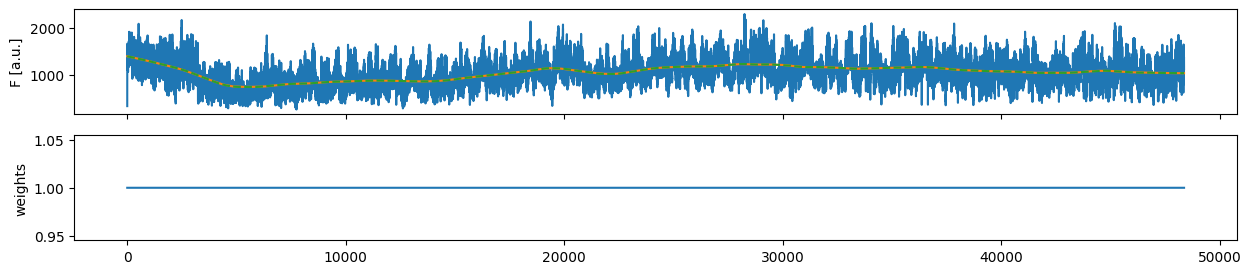

statsmodels : 12.9 ms
skmisc      : 23.6 ms
speedup     : 1.8x  (statsmodels faster = >1)
max |Δ|     : 5.52e+00
max rel |Δ| : 6.75e-03
mean rel |Δ|: 1.28e-03


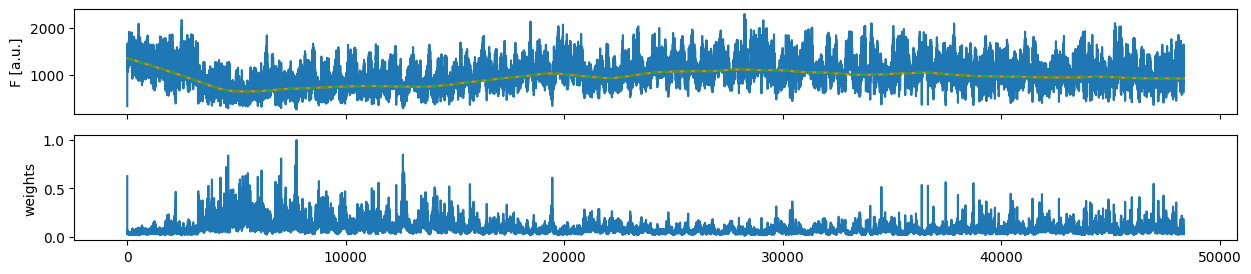

statsmodels : 11.8 ms
skmisc      : 23.5 ms
speedup     : 2.0x  (statsmodels faster = >1)
max |Δ|     : 1.19e+01
max rel |Δ| : 1.48e-02
mean rel |Δ|: 1.62e-03


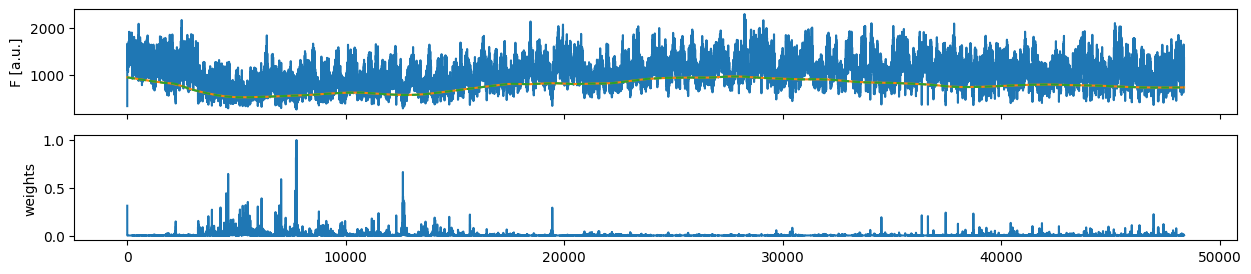

In [13]:
for weights in (np.ones_like(trace), 1/trace**2, 1/trace**5):
    weights/=weights.max()
    fluct_sm, fluct_sk = compare_lowess(trace, timestamps, weights=weights, frac=0.1)
    
    fig, ax = plt.subplots(2, 1, figsize=(15,3), sharex=True)
    ax[0].plot(trace)
    ax[0].plot(fluct_sm)
    ax[0].plot(fluct_sk, ls="--")
    ax[1].plot(weights)
    ax[0].set_ylabel("F [a.u.]")
    ax[1].set_ylabel("weights")
    plt.show()

## Fit using M-estimator weights  

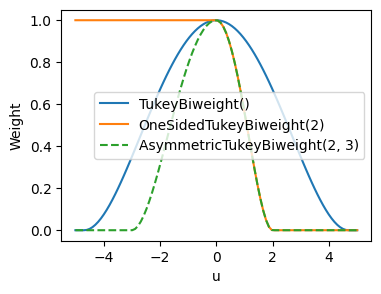

In [14]:
plt.figure(figsize=(4,3))
plt.plot(np.linspace(-5,5,100), TukeyBiweight().weights(np.linspace(-5,5,100)), label="TukeyBiweight()")
plt.plot(np.linspace(-5,5,100), OneSidedTukeyBiweight(2).weights(np.linspace(-5,5,100)), label="OneSidedTukeyBiweight(2)")
plt.plot(np.linspace(-5,5,100), AsymmetricTukeyBiweight(2, 3).weights(np.linspace(-5,5,100)), ls="--", label="AsymmetricTukeyBiweight(2, 3)")
plt.ylabel("Weight")
plt.xlabel("u")
plt.legend();

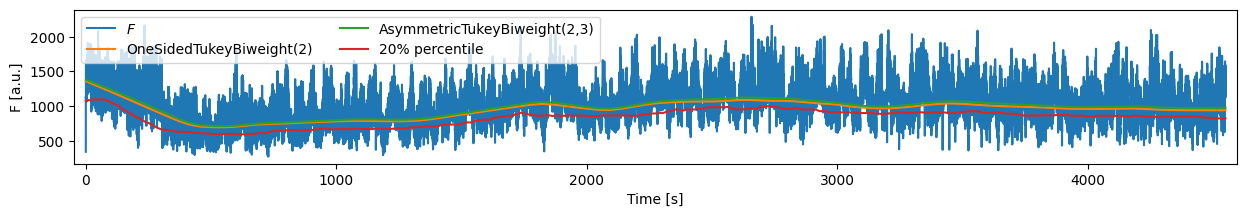

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(15,2))
ax.plot(timestamps, trace, label="$F$")
# LOWESS with robust IRLS
F0 = fit_baseline_fluctuations(trace, timestamps, method="lowess", M=OneSidedTukeyBiweight(2))[0]
ax.plot(timestamps, F0, label="OneSidedTukeyBiweight(2)")
F0 = fit_baseline_fluctuations(trace, timestamps, method="lowess", M=AsymmetricTukeyBiweight(2,3))[0]
ax.plot(timestamps, F0, label="AsymmetricTukeyBiweight(2,3)")
# percentile with explicit override
F0 = fit_baseline_fluctuations(trace, timestamps, method="percentile", percentile=20)[0]
ax.plot(timestamps, F0, label="20% percentile")
ax.set_xlim(-.01*timestamps[-1], 1.01*timestamps[-1])
ax.set_xlabel("Time [s]")
ax.set_ylabel("F [a.u.]")
plt.legend(ncol=2);

In [16]:
double_exp_bright_init = [trace[-1000:].mean(), 0.35, 0.2, 0.99, 3600, 240, 1e5]
double_exp_bright_bounds = [(0, np.inf)] * 4 + [(300, np.inf), (1, 1200), (1, np.inf)]

In [17]:
%%time
# numpy
F0trend, res = nonlinear_fit(trace, timestamps, double_exp_bright, double_exp_bright_init, bounds=double_exp_bright_bounds,
                             M=AsymmetricTukeyBiweight(2, 3),
                             optimizer="L-BFGS-B",
                             optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10),
                             backend="numpy")

CPU times: user 14.1 s, sys: 5.21 ms, total: 14.1 s
Wall time: 7.27 s


In [18]:
%%time
# jax
F0trend, res = nonlinear_fit(trace, timestamps, partial(double_exp_bright, xp=jnp), double_exp_bright_init, bounds=double_exp_bright_bounds,
                             M=AsymmetricTukeyBiweight(2, 3, jnp),
                             optimizer="L-BFGS-B",
                             optimizer_options=dict(maxiter=20000, ftol=1e-12, gtol=1e-10),
                             backend="jax")

CPU times: user 9.34 s, sys: 282 ms, total: 9.63 s
Wall time: 5.25 s


{'lowess_weights': array([0.        , 0.90797907, 0.78886086, ..., 0.14422927, 0.43575603,
       0.78767092], shape=(48374,))}
{'percentile': np.float64(40.17654111712904), 'size': 4837}
{'percentile': 20, 'size': 4837}


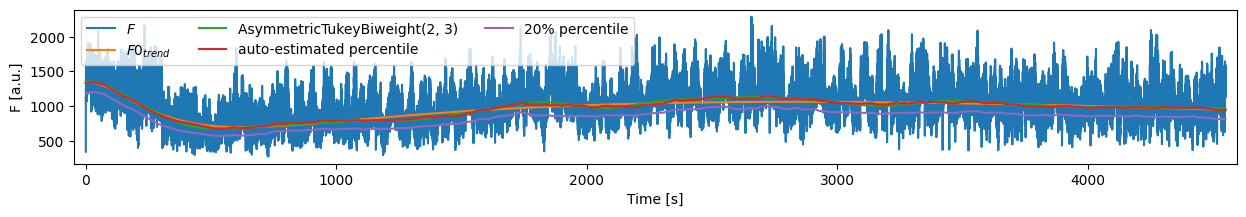

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(15,2))
ax.plot(timestamps, trace, label="$F$")
ax.plot(timestamps, F0trend, label="$F0_{trend}$")
# LOWESS with robust IRLS
F0, _, info = fit_baseline_fluctuations(trace, timestamps, trend=F0trend, weights=res.weights,
                          method="lowess", M=AsymmetricTukeyBiweight(2, 3))
print(info)
ax.plot(timestamps, F0, label="AsymmetricTukeyBiweight(2, 3)")
# percentile with auto-estimated q
F0, _, info = fit_baseline_fluctuations(trace, timestamps, trend=F0trend, weights=res.weights,
                          method="percentile")
print(info)
ax.plot(timestamps, F0, label="auto-estimated percentile")
# percentile with explicit override
F0, _, info = fit_baseline_fluctuations(trace, timestamps, trend=F0trend,
                          method="percentile", percentile=20)
print(info)
ax.plot(timestamps, F0, label="20% percentile")
ax.set_xlim(-.01*timestamps[-1], 1.01*timestamps[-1])
ax.set_xlabel("Time [s]")
ax.set_ylabel("F [a.u.]")
plt.legend(ncol=3);